In [37]:
import pandas as pd

# load dataset
df = pd.read_csv("../../data/processed/germany/regional_dashboard.csv")

# preprocessing
df["avg_travel_time"] = pd.to_timedelta(df["avg_travel_time"])
df["minutes"] = df["avg_travel_time"].dt.total_seconds() / 60

# extract train type
df["type"] = df["route_short_name"].str.extract(r'(^[A-Z]+)')

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# chart config
FIG_SIZE = (10, 5)
PALETTE = "viridis"

sns.set_style("whitegrid")

def clean_plot(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sns.despine()
    plt.tight_layout()

## **NETWORK SCALE & VOLUME - Germany**

In [39]:
print("Total segments:", len(df))
print("Total trips:", df["trip_count"].sum())

Total segments: 22559
Total trips: 477902


**Insight:**

- The German rail network operates at a large national scale, with extensive segment coverage and high service frequency.

## **TRAVEL TIME DISTRIBUTION**

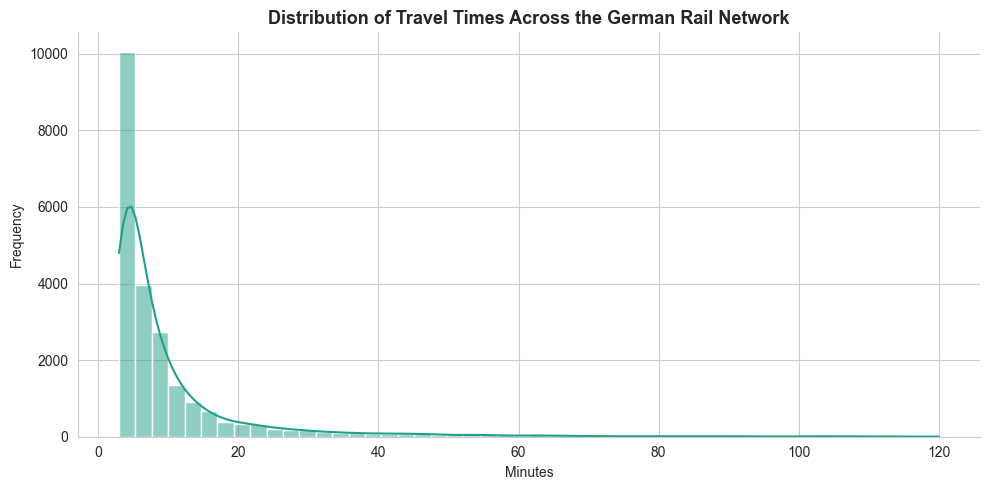

In [40]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.histplot(
    data=df,
    x="minutes",
    bins=50,
    kde=True,
    color=sns.color_palette(PALETTE)[3],
    ax=ax
)

clean_plot(
    ax,
    "Distribution of Travel Times Across the German Rail Network",
    "Minutes",
    "Frequency"
)
plt.show()

**Insight:**

- Right-skewed distribution → majority short regional trips
- Long tail → presence of long-distance intercity connections

## **SERVICE TYPE DISTRIBUTION**

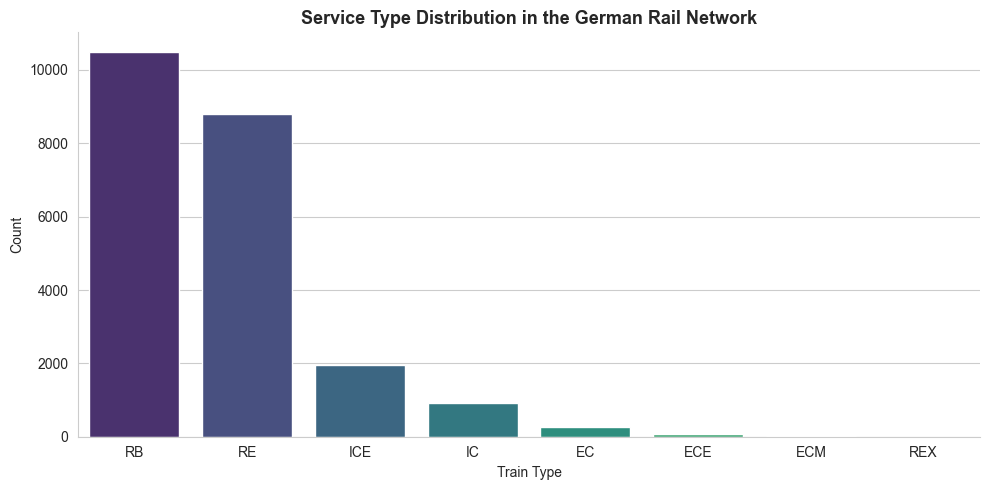

In [41]:
type_counts = df["type"].value_counts().reset_index()
type_counts.columns = ["type", "count"]

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=type_counts,
    x="type",
    y="count",
    hue="type",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Service Type Distribution in the German Rail Network",
    "Train Type",
    "Count"
)
plt.show()

**Insight:**

- Regional services (RB, RE) dominate → backbone of network
- ICE/IC lower count → high-speed long-distance services

## **TOP RAIL CORRIDOR**

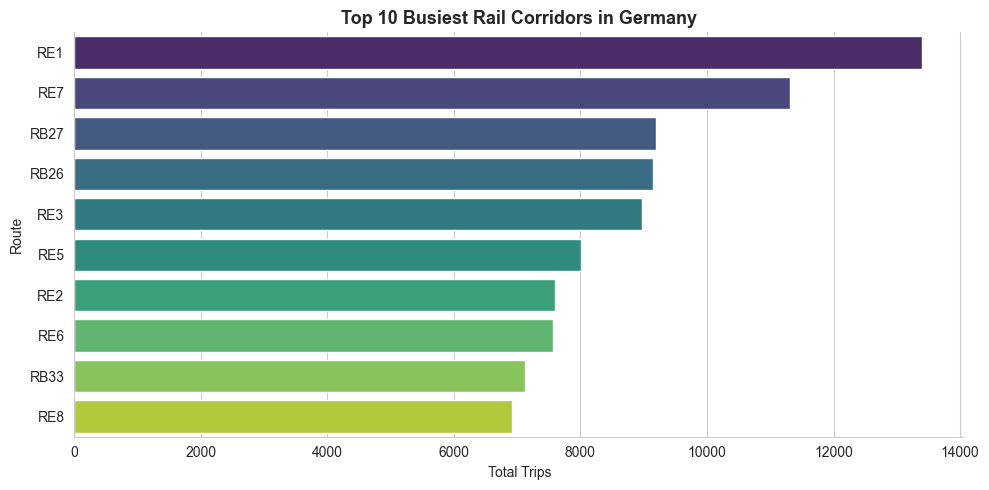

In [ ]:
corridor_demand = (
    df.groupby("route_short_name")["trip_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=corridor_demand,
    y="route_short_name",
    x="trip_count",
    hue="route_short_name",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Top 10 Most Frequent Rail Services (Germany)",
    "Total Trips",
    "Route"
)
plt.show()

**Insight:**

- Demand is concentrated in specific routes → commuter-heavy corridors
- Regional express lines dominate high-demand segments

## **TRAVEL TIME VARIABILITY**

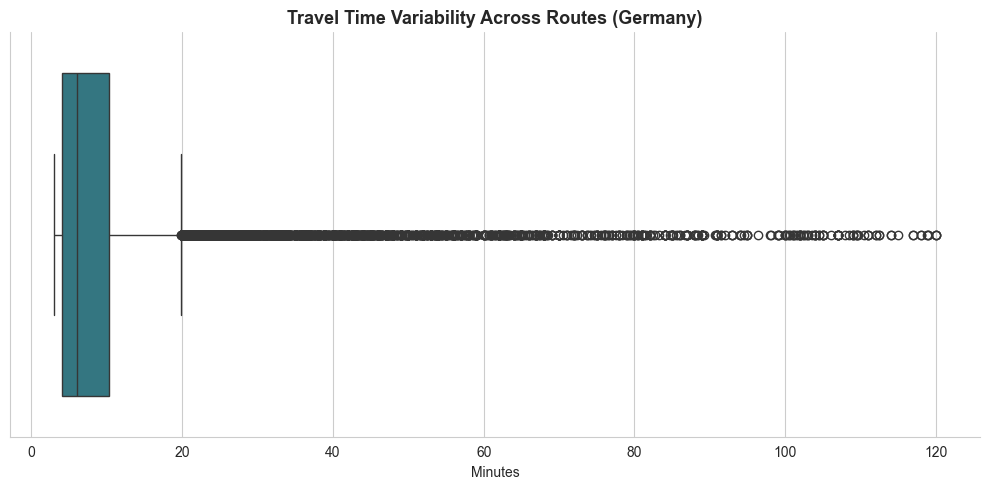

In [43]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.boxplot(
    data=df,
    x="minutes",
    color=sns.color_palette(PALETTE)[2],
    ax=ax
)

clean_plot(
    ax,
    "Travel Time Variability Across Routes (Germany)",
    "Minutes",
    ""
)
plt.show()

**Insight:**

- Wide spread reflects mix of short and long-distance services
- Outliers correspond to intercity and long-haul routes (not inefficiency)

## **NETWORK CENTRALITY**

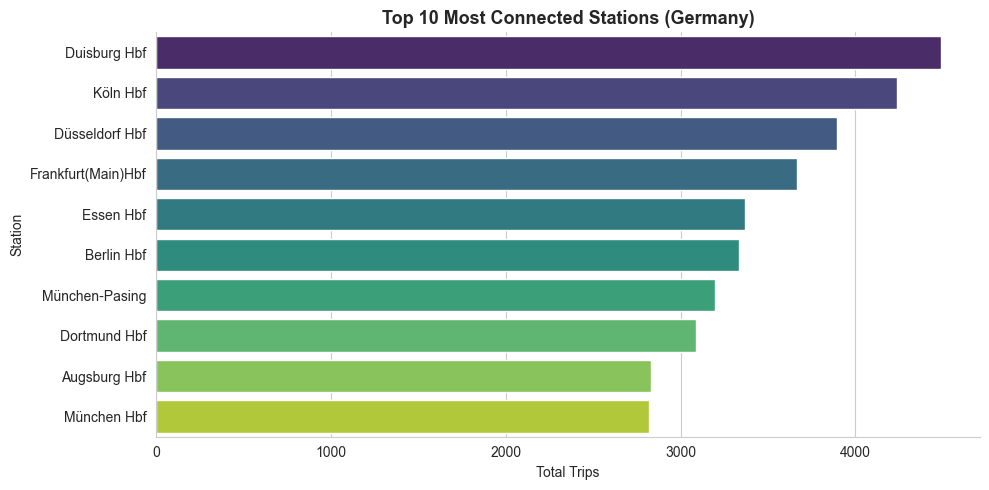

In [44]:
from_counts = df.groupby("prev_stop_name")["trip_count"].sum()
to_counts = df.groupby("stop_name")["trip_count"].sum()

station_usage = (
    from_counts.add(to_counts, fill_value=0)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

station_usage.columns = ["station", "total_trips"]

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.barplot(
    data=station_usage,
    y="station",
    x="total_trips",
    hue="station",
    palette=PALETTE,
    ax=ax
)

clean_plot(
    ax,
    "Top 10 Most Connected Stations (Germany)",
    "Total Trips",
    "Station"
)
plt.show()

**Insight:**

- Major hubs (Frankfurt, Köln, Berlin) dominate connectivity
- These stations act as central interchange nodes in the network

## **Key Insights**

- The German rail network exhibits a hierarchical structure: strong regional backbone (RB/RE) supported by high-speed intercity services (ICE/IC).

- Travel demand is concentrated in specific corridors, indicating dominant commuter and economic routes.

- Travel time distribution confirms a mix of short regional and long-distance intercity journeys.

- Variability in travel times reflects system diversity, not inefficiency.

- Major stations such as Frankfurt, Köln, and Berlin function as central hubs driving national connectivity.